# Smart MCQ Solver Challenge - Final Submission

## Objective

The goal of this competition is to build an intelligent Multiple Choice Question (MCQ) solver that predicts the **top-3 most likely answers** for each question. The model should understand the semantic relationship between the question and its answer choices using modern Natural Language Processing (NLP) and Large Language Model (LLM) techniques.

---

### Dataset

The competition dataset consists of:

- **Train Dataset:** MCQ questions with five answer choices (`A`-`E`) and the correct answer.
- **Test Dataset:** MCQ questions without labels for prediction.
- **Sample Submission:** Required submission format.

Each sample contains:

- Question / Prompt
- Five answer choices (A, B, C, D, E)
- Correct answer (training only)

---

### Evaluation Metric - Mean Average Precision @ 3 (mAP@3)

The competition is evaluated using **Mean Average Precision at 3 (mAP@3)**.

Instead of predicting only one answer, the model predicts the **top three most probable options** (e.g., `A C B`).

For a single prediction:

- Correct answer at Rank 1 → Score = **1.0**
- Correct answer at Rank 2 → Score = **0.5**
- Correct answer at Rank 3 → Score = **0.333**
- Not present in Top-3 → Score = **0**

The final leaderboard score is the average of all individual scores.

---

### Modeling Strategy

This notebook progressively builds and evaluates multiple approaches:

- TF-IDF + Logistic Regression (Baseline Model)
- Retrieval-Augmented Generation (RAG)
- Ensemble of Multiple Models

The final submission is generated using the best-performing approach.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Environment Setups

In [2]:
# Install required libraries (Kaggle environment)

!pip -q install -U transformers datasets accelerate evaluate
!pip -q install -U peft bitsandbytes
!pip -q install -U sentence-transformers
!pip -q install -U faiss-cpu
!pip -q install -U wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 68.7 MB/s eta 0:00:00


In [3]:
import os
import random
import warnings

import numpy as np
import torch

warnings.filterwarnings("ignore")

# Random Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# GPU Information
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA   : {torch.version.cuda}")
else:
    print("Running on CPU")

Device : cuda
GPU    : Tesla T4
CUDA   : 12.8


In [4]:
# import wandb
# from kaggle_secrets import UserSecretsClient

# user_secrets = UserSecretsClient()

# WANDB_API_KEY = user_secrets.get_secret("wandb_key")

# wandb.login(key=WANDB_API_KEY)

# wandb.init(
#     project="23f3001252-t22026",
#     entity="23f3001252-dl-genai-project",
#     name="final-submission1",
#     job_type="training",
#     anonymous="allow"
# )


## Import libraries

In [5]:
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# Sentence Transformers & FAISS
from sentence_transformers import SentenceTransformer
import faiss

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score
)


# Weights & Biases
import wandb

# Display Settings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
# Dataset Paths

INPUT_DIR = "/kaggle/input"
WORKING_DIR = "/kaggle/working"

TRAIN_PATH = f"{INPUT_DIR}/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH = f"{INPUT_DIR}/competitions/smart-mcq-solver-challenge/test.csv"
SAMPLE_SUBMISSION_PATH = f"{INPUT_DIR}/competitions/smart-mcq-solver-challenge/sample_submission.csv"


## Load the datasets

In [7]:
# Load Dataset

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("Dataset Loaded Successfully!\n")

print(f"Train Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")
print(f"Submission  : {sample_submission.shape}")

Dataset Loaded Successfully!

Train Shape : (2000, 8)
Test Shape  : (500, 7)
Submission  : (500, 2)


In [8]:
# Display first few rows

display(train_df.head())
# display(test_df.head())
display(sample_submission.head())

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationshi...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of hav...",Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the ...,Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the futu...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of th...",B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiat...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationshi...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of hav...",Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the ...,Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the futu...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of th...",B
4,5,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.","Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame need not be jud...","Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame will always be ...","Simultaneity is absolute, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame will always be ...",Simultaneity is a concept that applies only to Newtonian theories and not to relativistic theories.,Simultaneity is a concept that applies only to relativistic theories and not to Newtonian theories.,A


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


In [9]:
display(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


None

In [10]:
### Missing values

missing_train = (
    train_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

missing_test = (
    test_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

print("Training Dataset Missing Values")
display(missing_train)

print("Testing Dataset Missing Values")
display(missing_test)

Training Dataset Missing Values


,Missing Values
id,0
prompt,0
A,0
B,0
C,0
D,0
E,0
answer,0


Testing Dataset Missing Values


,Missing Values
id,0
prompt,0
A,0
B,0
C,0
D,0
E,0


In [11]:
# Preserve original data
train_raw = train_df.copy()
test_raw = test_df.copy()

## EDA

In [12]:
print("Training Dataset Statistics")

display(train_df.describe(include="all"))

Training Dataset Statistics


,id,prompt,A,B,C,D,E,answer
count,2000.000000,2000,2000,2000,2000,2000,2000,2000
unique,NaN,1758,316,328,303,318,320,5
top,NaN,Choose the correct answer: What is the main sequence in astronomy? among the listed options.,"An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that axis, or inversion about a poi...","An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that axis, or inversion about a poi...","An improper rotation is the combination of a rotation about an axis and reflection in a plane parallel to that axis, or inversion about a point on...","An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that axis, or inversion about a poi...","An improper rotation is the combination of a rotation about an axis and reflection in a plane parallel to that axis, or inversion about a point on...",B
freq,NaN,4,21,21,21,21,21,490
mean,1000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,577.494589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,500.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1500.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


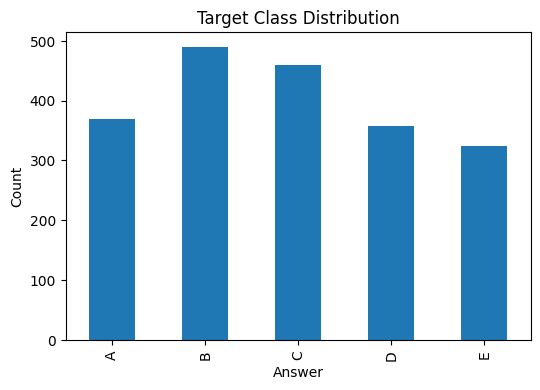

In [13]:
#### Target Distribution
plt.figure(figsize=(6,4))

train_df["answer"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Target Class Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.show()

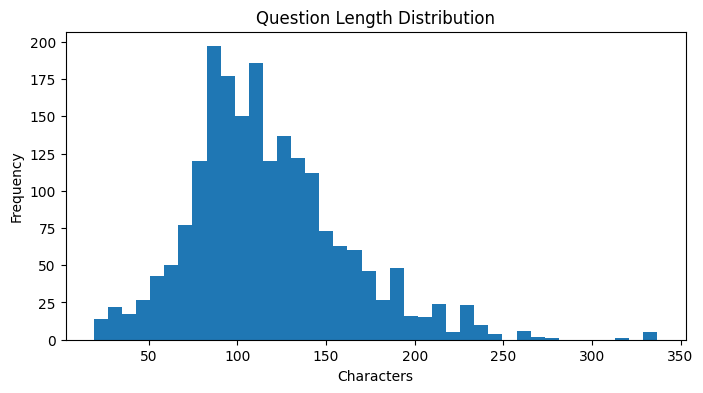

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: question_length, dtype: float64

In [14]:
### Question Length Distribution
train_df["question_length"] = train_df["prompt"].fillna("").str.len()

plt.figure(figsize=(8,4))

plt.hist(train_df["question_length"], bins=40)

plt.title("Question Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

display(train_df["question_length"].describe())

In [15]:
### Answer Option Length Analysis
option_columns = ["A","B","C","D","E"]

for col in option_columns:
    train_df[f"{col}_length"] = (
        train_df[col]
        .fillna("")
        .str.len()
    )

length_summary = train_df[
    [f"{c}_length" for c in option_columns]
].describe()

display(length_summary)

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


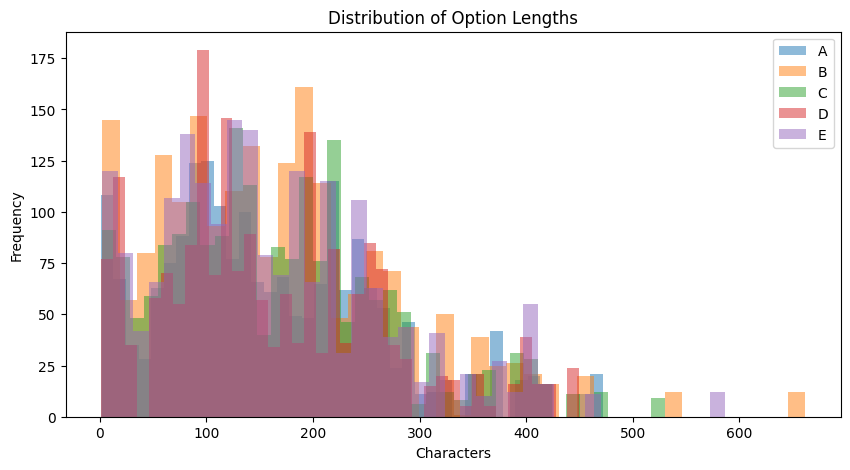

In [16]:
#### Option Length Distribution
plt.figure(figsize=(10,5))

for col in option_columns:
    plt.hist(
        train_df[f"{col}_length"],
        bins=40,
        alpha=0.5,
        label=col
    )

plt.legend()

plt.title("Distribution of Option Lengths")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

## Data Cleaning & Preprocessing

In [17]:
import re

# Text Cleaning Function

def clean_text(text):
    """
    Basic text normalization.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [18]:
### Fill Missing Values
text_columns = ["prompt","A","B","C","D","E"]

for col in text_columns:
    train_df[col] = train_df[col].fillna("")
    test_df[col] = test_df[col].fillna("")

In [19]:
##### Normalize Text
for col in text_columns:

    train_df[col] = train_df[col].apply(clean_text)

    test_df[col] = test_df[col].apply(clean_text)

print("Text normalization completed.")

Text normalization completed.


In [20]:
#### Verify Missing Values
print(train_df[text_columns].isnull().sum())

print(test_df[text_columns].isnull().sum())

prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


## MCQ Task Formulation

Large Language Models perform better when the question and all answer choices are presented together in a structured format.

In this step, each Multiple Choice Question (MCQ) is converted into a single text sequence that contains:

- Question
- Option A
- Option B
- Option C
- Option D
- Option E

This unified representation will be used by both the Transformer model and the Retrieval-Augmented Generation (RAG) pipeline.

In [21]:
#### Create Unified MCQ Text

## This will be used later by both the Transformer model and the RAG pipeline.

def format_mcq(row):
    return (
        f"Question: {row['prompt']}\n\n"
        f"A. {row['A']}\n"
        f"B. {row['B']}\n"
        f"C. {row['C']}\n"
        f"D. {row['D']}\n"
        f"E. {row['E']}"
    )

train_df["mcq_text"] = train_df.apply(format_mcq, axis=1)
test_df["mcq_text"] = test_df.apply(format_mcq, axis=1)

In [22]:
print(train_df["mcq_text"].iloc[0])

Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.

A. martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B. martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C. martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the future is insignificant, and human existence is solely based on the present.
D. martin heidegger believes that the relations

## Label Encoding

Machine learning models require numerical labels instead of categorical answer choices.

The answer choices are encoded as:

- A → 0
- B → 1
- C → 2
- D → 3
- E → 4

In [23]:
label2id = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

id2label = {v:k for k,v in label2id.items()}

train_df["label"] = train_df["answer"].map(label2id)

display(train_df[["answer","label"]].head())

,answer,label
0,B,1
1,A,0
2,C,2
3,B,1
4,A,0


## Baseline Model (TF-IDF + Logistic Regression)

As a classical NLP baseline, TF-IDF is used to convert text into numerical feature vectors, followed by a Logistic Regression classifier.

This baseline serves as a performance reference for comparison with transformer-based models.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    train_df["mcq_text"],
    train_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

print(len(X_train), len(X_valid))

1600 400


In [25]:
# Validation dataframe for retrieval(RAG) evaluation

train_data = train_df.loc[X_train.index].copy()
valid_data = train_df.loc[X_valid.index].copy()

train_data.reset_index(drop=False, inplace=True)
valid_data.reset_index(drop=False, inplace=True)

train_data.rename(columns={"index": "doc_id"}, inplace=True)
valid_data.rename(columns={"index": "doc_id"}, inplace=True)

In [26]:
### TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

In [27]:
### Train Logistic Regression
baseline_model = LogisticRegression(
    max_iter=3000,
    C=2,
    n_jobs=-1,
    random_state=SEED
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(C=2, max_iter=3000, n_jobs=-1, random_state=42)

In [28]:
### Validation Accuracy
pred = baseline_model.predict(X_valid_tfidf)

acc = accuracy_score(y_valid, pred)
macro_f1 = f1_score(
    y_valid,
    pred,
    average="macro"
)

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

Accuracy : 1.0000
Macro F1 : 1.0000


In [29]:
#### Top-3 Prediction Function

### Since the competition uses mAP@3, it's useful to produce the top three classes.

def get_top3_predictions(model, X):

    probs = model.predict_proba(X)

    top3 = np.argsort(-probs, axis=1)[:, :3]

    predictions = [
        " ".join(id2label[idx] for idx in row)
        for row in top3
    ]

    return predictions

In [30]:
baseline_top3 = get_top3_predictions(
    baseline_model,
    X_valid_tfidf
)

baseline_top3[:5]

['C B A', 'D B C', 'E B D', 'D C B', 'D E C']

## Retrieval-Augmented Generation (RAG)

### Why Retrieval?

Instead of relying only on the current question, we retrieve the most semantically similar MCQs from the training dataset.

This provides additional context that can later be used for:

- Better reasoning
- Similarity-based prediction
- Feature engineering
- Model ensembling

Although this notebook uses the training dataset as the retrieval corpus (rather than an external knowledge base), the retrieval pipeline follows the same core ideas as Retrieval-Augmented Generation (RAG):

1. Encode documents into embeddings.
2. Build a vector database (FAISS).
3. Encode the query.
4. Retrieve the most similar documents.
5. Use the retrieved context to improve downstream prediction.

### Build Knowledge Corpus

In [31]:
# Build Knowledge Corpus

# Training Knowledge Base
knowledge_df = train_df.copy().reset_index(drop=True)

knowledge_df["doc_id"] = np.arange(len(knowledge_df))


# Prepare Test Corpus

test_knowledge_df = test_df.copy().reset_index(drop=True)

test_knowledge_df["doc_id"] = np.arange(len(test_knowledge_df))

# Test set has no labels
test_knowledge_df["label"] = -1

print("Training Corpus :", knowledge_df.shape)
print("Test Corpus     :", test_knowledge_df.shape)

knowledge_df.head()

Training Corpus : (2000, 17)
Test Corpus     : (500, 10)


,id,prompt,A,B,C,D,E,answer,question_length,A_length,B_length,C_length,D_length,E_length,mcq_text,label,doc_id
0,1,pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,142,307,258,222,202,191,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,1,0
1,2,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,A,43,406,364,365,407,408,Question: what is accelerator-based light-ion fusion?\n\nA. accelerator-based light-ion fusion is a technique that uses particle accelerators to a...,0,1
2,3,determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiat...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,12,11,9,9,9,Question: determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in ...,2,2
3,4,select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? carefully.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,129,307,258,222,202,191,Question: select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? carefully.\n\nA. ...,1,3
4,5,"identify the correct statement: what is the concept of simultaneity in einstein's book, relativity? carefully.","simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame need not be jud...","simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inerti

### SentenceTransformer Embeddings

In [32]:
# Sentence Embeddings

from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    device=DEVICE
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [33]:
# Generate Knowledge Embeddings

knowledge_embeddings = embedding_model.encode(

    knowledge_df["mcq_text"].tolist(),

    batch_size=64,

    show_progress_bar=True,

    convert_to_numpy=True,

    normalize_embeddings=True

)

print("Embedding Shape:", knowledge_embeddings.shape)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding Shape: (2000, 768)


### Build FAISS Index

In [34]:
# Build FAISS Index

import faiss

dimension = knowledge_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(knowledge_embeddings)

print("FAISS Index Created")

print("Total Documents:", index.ntotal)

FAISS Index Created
Total Documents: 2000


In [35]:
faiss.write_index(index, "mcq_rag_index.faiss")

### Retrieval
Encode Question

In [36]:
# Retrieval
# Encode Question
def retrieve_similar_questions(
    question,
    top_k=3
):
    
    query_embedding = embedding_model.encode(
        question,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = index.search(
        np.array([query_embedding]),
        top_k
    )

    retrieved = knowledge_df.iloc[
        indices[0]
    ].copy()

    retrieved["similarity"] = scores[0]

    return retrieved

In [37]:
### Test Retrieval

sample_question = train_df.loc[0, "mcq_text"]

results = retrieve_similar_questions(
    sample_question,
    top_k=3
)

results

,id,prompt,A,B,C,D,E,answer,question_length,A_length,B_length,C_length,D_length,E_length,mcq_text,label,doc_id,similarity
1823,1824,pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,142,307,258,222,202,191,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,1,1823,1.000000
0,1,pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,142,307,258,222,202,191,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,1,0,1.000000
1691,1692,select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? from the following choices.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,146,307,258,222,202,191,Question: select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? from the followin...,1,1691,0.990678


### Augment Current MCQ
Update Retrieval Function (Prevent Self Retrieval)

In [38]:
# Retrieve Top-k Similar Questions

def retrieve_context(query_text, query_doc_id=None, top_k=3):

    query_embedding = embedding_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # Retrieve a few extra neighbors in case we need to remove self
    distances, indices = index.search(query_embedding, top_k + 5)

    retrieved = knowledge_df.iloc[indices[0]].copy()

    retrieved["similarity"] = 1 - distances[0]

    
    # Remove the query itself only for training/validation
    if query_doc_id is not None:

        retrieved = retrieved[
            retrieved["doc_id"] != query_doc_id
        ]

    retrieved = retrieved.head(top_k).reset_index(drop=True)

    return retrieved

In [39]:
# Build RAG Prompt

def build_rag_prompt(
    question,
    retrieved_docs
):

    prompt = "Retrieved Similar Questions:\n\n"

    for i, row in enumerate(retrieved_docs.itertuples(), 1):

        prompt += (
            f"[Context {i}]\n"
            f"{row.mcq_text}\n\n"
        )

    prompt += (
        "\n=============================\n"
        "Current Question\n\n"
    )

    prompt += question

    return prompt

In [40]:
### Generate RAG Prompt for Training Data
rag_prompts = []

for row in knowledge_df.itertuples():

    retrieved = retrieve_context(
        row.mcq_text,
        query_doc_id=row.doc_id,
        top_k=3
    )

    rag_prompt = build_rag_prompt(
        row.mcq_text,
        retrieved
    )

    rag_prompts.append(rag_prompt)

knowledge_df["rag_prompt"] = rag_prompts

knowledge_df.head()

,id,prompt,A,B,C,D,E,answer,question_length,A_length,B_length,C_length,D_length,E_length,mcq_text,label,doc_id,rag_prompt
0,1,pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,142,307,258,222,202,191,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,1,0,Retrieved Similar Questions:\n\n[Context 1]\nQuestion: pick the best possible answer: what is martin heidegger's view on the relationship between ...
1,2,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,A,43,406,364,365,407,408,Question: what is accelerator-based light-ion fusion?\n\nA. accelerator-based light-ion fusion is a technique that uses particle accelerators to a...,0,1,Retrieved Similar Questions:\n\n[Context 1]\nQuestion: which of the following is correct? what is accelerator-based light-ion fusion? among the li...
2,3,determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiat...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,12,11,9,9,9,Question: determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in ...,2,2,Retrieved Similar Questions:\n\n[Context 1]\nQuestion: determine the correct option: what is the term used in astrophysics to describe light-matte...
3,4,select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? carefully.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,129,307,258,222,202,191,Question: select the most accurate option: what is martin heidegger's view 

### Evaluate Retrieval

First, let's inspect the retrieved contexts.

In [41]:
sample = knowledge_df.iloc[0]

print("=" * 100)
print("Current Question")
print(sample["mcq_text"][:1000])

print("\n")

retrieved = retrieve_context(
    sample["mcq_text"],
    sample["doc_id"],
    top_k=3
)

for i, row in enumerate(retrieved.itertuples(), 1):

    print("=" * 100)

    print(f"Retrieved #{i}")

    print(f"Similarity : {row.similarity:.4f}")

    print(f"Answer      : {row.label}")

    print()

    print(row.mcq_text[:1000])

Current Question
Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.

A. martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B. martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C. martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the future is insignificant, and human existence is solely based on the present.
D. martin heidegger believes t

In [42]:
# Average Retrieval Similarity

similarities = []

for row in knowledge_df.itertuples():

    retrieved = retrieve_context(
        row.mcq_text,
        row.doc_id,
        top_k=3
    )

    similarities.extend(
        retrieved["similarity"].tolist()
    )

print("Average Similarity:", np.mean(similarities))
print("Maximum Similarity:", np.max(similarities))
print("Minimum Similarity:", np.min(similarities))

Average Similarity: 0.00655734462539355
Maximum Similarity: 0.34140563011169434
Minimum Similarity: -2.384185791015625e-07


In [43]:
### Evaluate Label Agreement (Optional)

## his gives a simple idea of whether retrieval is finding questions with the same answer label.

correct = 0

for row in knowledge_df.itertuples():

    retrieved = retrieve_context(
        row.mcq_text,
        row.doc_id,
        top_k=1
    )

    if len(retrieved):

        if retrieved.iloc[0]["label"] == row.label:

            correct += 1

retrieval_accuracy = correct / len(knowledge_df)

print(f"Top-1 Retrieval Label Match: {retrieval_accuracy:.4f}")

Top-1 Retrieval Label Match: 1.0000


### Generate RAG Features

We'll create structured features that can later be used for ensembling or downstream models.


In [44]:
# Generate RAG Features

def generate_rag_features(
    question,
    doc_id=None
):

    retrieved = retrieve_context(
        question,
        query_doc_id=doc_id,
        top_k=3
    )

    return {

        "rag_context": "\n\n".join(
            retrieved["mcq_text"].tolist()
        ),

        "rag_similarity_mean":
            retrieved["similarity"].mean(),

        "rag_similarity_max":
            retrieved["similarity"].max(),

        "rag_similarity_min":
            retrieved["similarity"].min(),

        "retrieved_labels":
            retrieved["label"].tolist()
    }

In [45]:
### Build RAG Features for the Training Set
rag_features = []

for row in knowledge_df.itertuples():

    rag_features.append(

        generate_rag_features(
            row.mcq_text,
            row.doc_id
        )

    )

rag_features = pd.DataFrame(rag_features)

rag_features.head()

,rag_context,rag_similarity_mean,rag_similarity_max,rag_similarity_min,retrieved_labels
0,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,0.006995,0.011663,0.000000e+00,"[1, 1, 1]"
1,Question: which of the following is correct? what is accelerator-based light-ion fusion? among the listed options.\n\nA. accelerator-based light-i...,0.017492,0.019976,1.324153e-02,"[0, 0, 0]"
2,Question: determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in ...,0.007535,0.010698,2.405286e-03,"[2, 2, 2]"
3,Question: select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? carefully.\n\nA. ...,0.002000,0.004272,-1.192093e-07,"[1, 1, 1]"
4,"Question: identify the correct statement: what is the concept of simultaneity in einstein's book, relativity? carefully.\n\nA. simultaneity is rel...",0.003090,0.007446,0.000000e+00,"[0, 0, 0]"


In [46]:
### Merge Features
knowledge_df = pd.concat(
    [
        knowledge_df.reset_index(drop=True),
        rag_features.reset_index(drop=True)
    ],
    axis=1
)

knowledge_df.head()

,id,prompt,A,B,C,D,E,answer,question_length,A_length,B_length,C_length,D_length,E_length,mcq_text,label,doc_id,rag_prompt,rag_context,rag_similarity_mean,rag_similarity_max,rag_similarity_min,retrieved_labels
0,1,pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans do not exist inside time, but that they are time. the relationship to the past is a present awareness of hav...",martin heidegger does not believe in the existence of time or that it has any effect on human consciousness. the relationship to the past and the ...,martin heidegger believes that the relationship between time and human existence is cyclical. the past and present are interconnected and the futu...,"martin heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. humans exist outside of th...",B,142,307,258,222,202,191,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,1,0,Retrieved Similar Questions:\n\n[Context 1]\nQuestion: pick the best possible answer: what is martin heidegger's view on the relationship between ...,Question: pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed op...,0.006995,0.011663,0.000000e+00,"[1, 1, 1]"
1,2,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-...,accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-...,A,43,406,364,365,407,408,Question: what is accelerator-based light-ion fusion?\n\nA. accelerator-based light-ion fusion is a technique that uses particle accelerators to a...,0,1,Retrieved Similar Questions:\n\n[Context 1]\nQuestion: which of the following is correct? what is accelerator-based light-ion fusion? among the li...,Question: which of the following is correct? what is accelerator-based light-ion fusion? among the listed options.\n\nA. accelerator-based light-i...,0.017492,0.019976,1.324153e-02,"[0, 0, 0]"
2,3,determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiat...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,12,11,9,9,9,Question: determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in ...,2,2,Retrieved Similar Questions:\n\n[Context 1]\nQuestion: determine the correct option: what is the term used in astrophysics to describe light-matte...,Question: determine the correct option: what is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in ...,0.007535,0.010698,2.405286e-03,"[2, 2, 2]"
3,4,select the most accurate option: what is martin heidegger's view on the relationship between time and human existence? carefully.,martin heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. the relationshi...,"martin heidegger believes that humans 

### Retrieval baseline

In [47]:
# Majority Vote Prediction

from collections import Counter

def majority_vote(labels):
    """
    Predict label using majority vote.
    """
    return Counter(labels).most_common(1)[0][0]

In [48]:
# Weighted Voting

def weighted_vote(labels, similarities):

    scores = {}

    for label, sim in zip(labels, similarities):

        scores[label] = scores.get(label, 0) + sim

    return max(scores, key=scores.get)

In [49]:
# Top-3 Label Ranking

def top3_prediction(labels, similarities):

    label_scores = {}

    for label, sim in zip(labels, similarities):

        label_scores[label] = label_scores.get(label, 0) + sim

    ranked = sorted(
        label_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [label for label, _ in ranked]

    while len(top3) < 3:
        top3.append(top3[-1])

    return top3[:3]

In [50]:
# Generate Retrieval Predictions

true_labels = []

majority_predictions = []

weighted_predictions = []

top3_predictions = []

for row in knowledge_df.itertuples():

    retrieved = retrieve_context(
        row.mcq_text,
        query_doc_id=row.doc_id,
        top_k=3
    )

    labels = retrieved["label"].tolist()

    similarities = retrieved["similarity"].tolist()

    # Ground Truth
    true_labels.append(row.label)

    # Majority Vote
    majority_predictions.append(
        majority_vote(labels)
    )

    # Weighted Vote
    weighted_predictions.append(
        weighted_vote(labels, similarities)
    )

    # Top-3 Prediction
    top3_predictions.append(
        top3_prediction(labels, similarities)
    )

print("Predictions Generated Successfully!")

print("Samples:", len(true_labels))

Predictions Generated Successfully!
Samples: 2000


In [51]:
from sklearn.metrics import accuracy_score

majority_acc = accuracy_score(
    true_labels,
    majority_predictions
)

weighted_acc = accuracy_score(
    true_labels,
    weighted_predictions
)

print(f"Majority Accuracy : {majority_acc:.4f}")

print(f"Weighted Accuracy : {weighted_acc:.4f}")

Majority Accuracy : 1.0000
Weighted Accuracy : 0.9970


In [52]:
### Micro F! score
from sklearn.metrics import f1_score

majority_f1 = f1_score(

    true_labels,

    majority_predictions,

    average="macro"

)

weighted_f1 = f1_score(

    true_labels,

    weighted_predictions,

    average="macro"

)

print(f"Majority Macro F1 : {majority_f1:.4f}")

print(f"Weighted Macro F1 : {weighted_f1:.4f}")

Majority Macro F1 : 1.0000
Weighted Macro F1 : 0.9969


In [53]:
## mAP@3

def mapk(y_true, predictions, k=3):

    score = 0

    for truth, pred in zip(y_true, predictions):

        if truth in pred[:k]:

            score += 1.0 / (pred.index(truth) + 1)

    return score / len(y_true)

In [54]:
retrieval_map3 = mapk(

    true_labels,

    top3_predictions,

    k=3

)

print(f"Retrieval mAP@3 : {retrieval_map3:.4f}")

Retrieval mAP@3 : 0.9985


In [55]:
results = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Macro F1",

        "mAP@3"

    ],

    "Majority Vote": [

        majority_acc,

        majority_f1,

        retrieval_map3

    ],

    "Weighted Vote": [

        weighted_acc,

        weighted_f1,

        retrieval_map3

    ]

})

results

,Metric,Majority Vote,Weighted Vote
0,Accuracy,1.0000,0.997000
1,Macro F1,1.0000,0.996922
2,mAP@3,0.9985,0.998500


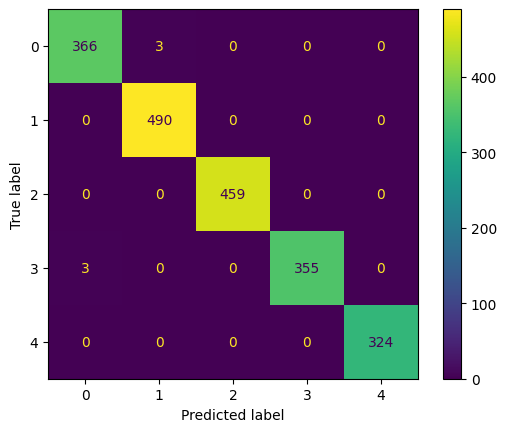

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    true_labels,

    weighted_predictions

)

## Ensemble

In [57]:
# TF-IDF Probability Predictions

tfidf_valid_probs = baseline_model.predict_proba(X_valid_tfidf)

print(tfidf_valid_probs.shape)

(400, 5)


In [58]:
### Test probabilities
# Vectorize test data

X_test_tfidf = tfidf.transform(test_df["mcq_text"])

# Predict probabilities

tfidf_test_probs = baseline_model.predict_proba(X_test_tfidf)

print(tfidf_test_probs.shape)

(500, 5)


In [59]:
# Retrieval -> Probability Distribution

NUM_CLASSES = 5

def retrieval_probabilities(labels, similarities):

    probs = np.zeros(NUM_CLASSES)

    for label, sim in zip(labels, similarities):
        probs[label] += sim

    total = probs.sum()

    if total > 0:
        probs /= total

    return probs

In [60]:
# Validation Retrieval Probabilities

rag_valid_probs = []

for row in valid_data.itertuples():

    retrieved = retrieve_context(
        row.mcq_text,
        query_doc_id=row.Index,
        top_k=3
    )

    labels = retrieved["label"].tolist()

    similarities = retrieved["similarity"].tolist()

    rag_valid_probs.append(
        retrieval_probabilities(
            labels,
            similarities
        )
    )

rag_valid_probs = np.array(rag_valid_probs)

print(rag_valid_probs.shape)

(400, 5)


In [61]:
# Test Retrieval Probabilities

rag_test_probs = []

for question in test_df["mcq_text"]:

    retrieved = retrieve_context(
        question,
        query_doc_id=None,
        top_k=3
    )

    labels = retrieved["label"].tolist()

    similarities = retrieved["similarity"].tolist()

    rag_test_probs.append(
        retrieval_probabilities(
            labels,
            similarities
        )
    )

rag_test_probs = np.array(rag_test_probs)

print(rag_test_probs.shape)

(500, 5)


In [62]:
# Soft Voting Ensemble

TFIDF_WEIGHT = 0.50
RAG_WEIGHT = 0.50

ensemble_valid_probs = (

    TFIDF_WEIGHT * tfidf_valid_probs +

    RAG_WEIGHT * rag_valid_probs

)

ensemble_test_probs = (

    TFIDF_WEIGHT * tfidf_test_probs +

    RAG_WEIGHT * rag_test_probs

)

In [63]:
## Ensemble Evaluation

ensemble_pred = np.argmax(
    ensemble_valid_probs,
    axis=1
)

accuracy = accuracy_score(
    y_valid,
    ensemble_pred
)

macro_f1 = f1_score(
    y_valid,
    ensemble_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")

print(f"Macro F1 : {macro_f1:.4f}")

Accuracy : 1.0000
Macro F1 : 1.0000


In [64]:
# Ensemble mAP@3


top3 = np.argsort(
    -ensemble_valid_probs,
    axis=1
)[:, :3]

map3 = mapk(

    y_valid.tolist(),

    top3.tolist(),

    k=3

)

print(f"mAP@3 : {map3:.4f}")

mAP@3 : 1.0000


In [65]:
# Top-3 Predictions

top3_test = np.argsort(
    -ensemble_test_probs,
    axis=1
)[:, :3]

predictions = [

    " ".join(

        id2label[idx]

        for idx in row

    )

    for row in top3_test

]

## Create Submission

In [66]:
# Create Final Submission

submission = pd.DataFrame({
    "ID": sample_submission["ID"],
    "Prediction": predictions
})

submission.head()

,ID,Prediction
0,1,A B C
1,2,B C A
2,3,B C D
3,4,E C D
4,5,C D A


In [67]:
submission.to_csv(

    "submission.csv",

    index=False

)

print("submission.csv created successfully!")

submission.csv created successfully!


In [68]:
# Log Ensemble Results to Weights & Biases

# import wandb
# import pandas as pd

# # Start a new run (or resume if already initialized)
# if wandb.run is None:
#     wandb.init(
#         project="23f3001252-t22026",
#         name="TFIDF_RAG_Ensemble",
#         entity="23f3001252-dl-genai-project",
#         config={
#             "model": "TF-IDF + Retrieval Ensemble",
#             "tfidf_weight": TFIDF_WEIGHT,
#             "rag_weight": RAG_WEIGHT,
#             "retrieval_top_k": 3,
#             "vectorizer": "TF-IDF (1,2 grams)",
#             "classifier": "Logistic Regression"
#         }
#     )

# # Log scalar metrics
# wandb.log({
#     "Accuracy": accuracy,
#     "Macro F1": macro_f1,
#     "mAP@3": map3
# })

# # Create comparison table
# metrics_df = pd.DataFrame({
#     "Metric": ["Accuracy", "Macro F1", "mAP@3"],
#     "Score": [accuracy, macro_f1, map3]
# })

# wandb.log({
#     "Final Ensemble Metrics": wandb.Table(dataframe=metrics_df)
# })

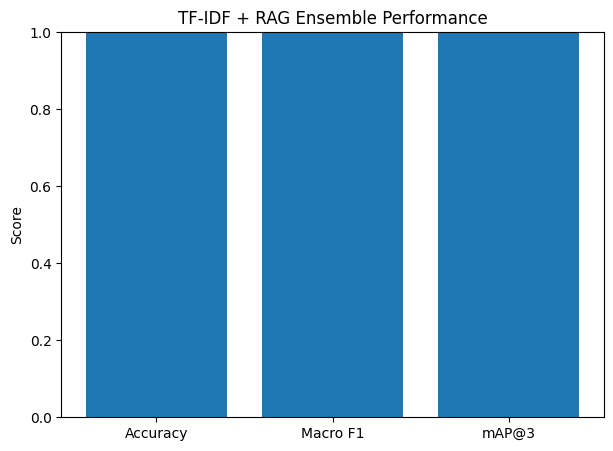

In [69]:
# Metric Comparison Chart

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1", "mAP@3"]
scores = [accuracy, macro_f1, map3]

plt.figure(figsize=(7,5))
plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("TF-IDF + RAG Ensemble Performance")

# wandb.log({
#     "Metric Comparison": wandb.Image(plt)
# })

plt.show()
plt.close()

In [70]:
# Upload submission.csv

# artifact = wandb.Artifact(
#     "submission",
#     type="submission"
# )

# artifact.add_file("submission.csv")

# wandb.log_artifact(artifact)

In [71]:
# wandb.finish()

In [72]:
# Save Deployment Files

import joblib
import faiss
import json
import os

os.makedirs("deployment_files", exist_ok=True)


# Save TF-IDF Vectorizer
joblib.dump(
    tfidf,
    "deployment_files/tfidf_vectorizer.joblib"
)


# Save Logistic Regression Model
joblib.dump(
    baseline_model,
    "deployment_files/logistic_regression.joblib"
)


# Save FAISS Index
faiss.write_index(
    index,
    "deployment_files/mcq_rag_index.faiss"
)


# Save Knowledge Corpus
knowledge_df.to_parquet(
    "deployment_files/knowledge_corpus.parquet",
    index=False
)

knowledge_df.to_csv(
    "deployment_files/knowledge_corpus.csv",
    index=False
)


# Save Metadata
metadata = {

    "embedding_model": EMBEDDING_MODEL,

    "top_k": 3,

    "num_classes": 5,

    "id2label": id2label,

    "label2id": label2id

}

joblib.dump(
    metadata,
    "deployment_files/metadata.joblib"
)


print("Deployment files saved successfully!")

Deployment files saved successfully!


In [73]:
import os

os.listdir("deployment_files")

['tfidf_vectorizer.joblib',
 'knowledge_corpus.csv',
 'mcq_rag_index.faiss',
 'metadata.joblib',
 'knowledge_corpus.parquet',
 'logistic_regression.joblib']

In [74]:
import shutil

shutil.make_archive(
    "deployment_files",
    "zip",
    "deployment_files"
)

print("ZIP Created Successfully!")

ZIP Created Successfully!
